# EgoCom EDA for OcularClaw

This notebook is a practical exploratory pass over the EgoCom dataset and the annotation artifacts prepared for the OcularClaw pilot.

It focuses on three things:
- dataset-level structure from `video_info.csv`
- transcript timing and speaker dynamics from `ground_truth_transcriptions.csv`
- the current 60-second host-perspective annotation windows in `analysis/`


In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)

REPO_ROOT = Path('/Users/matthewtaruno/Dev/OcularClaw')
DATA_ROOT = Path('/Users/matthewtaruno/Dev/EgoCom-Dataset/egocom_dataset')

VIDEO_INFO_PATH = DATA_ROOT / 'video_info.csv'
TRANSCRIPTS_PATH = DATA_ROOT / 'ground_truth_transcriptions.csv'
WINDOWS_PATH = REPO_ROOT / 'analysis' / 'egocom_annotation_windows_test_host_enriched.csv'

VIDEO_INFO_PATH, TRANSCRIPTS_PATH, WINDOWS_PATH


(PosixPath('/Users/matthewtaruno/Dev/EgoCom-Dataset/egocom_dataset/video_info.csv'),
 PosixPath('/Users/matthewtaruno/Dev/EgoCom-Dataset/egocom_dataset/ground_truth_transcriptions.csv'),
 PosixPath('/Users/matthewtaruno/Dev/OcularClaw/analysis/egocom_annotation_windows_test_host_enriched.csv'))

In [13]:
video_info = pd.read_csv(VIDEO_INFO_PATH)
transcripts = pd.read_csv(TRANSCRIPTS_PATH)
windows = pd.read_csv(WINDOWS_PATH)

numeric_video_cols = ['video_id', 'video_speaker_id', 'num_speakers', 'duration_seconds', 'word_count']
for col in numeric_video_cols:
    video_info[col] = pd.to_numeric(video_info[col], errors='coerce')

bool_video_cols = ['speaker_is_host', 'native_speaker', 'background_fan', 'background_music', 'train', 'val', 'test']
for col in bool_video_cols:
    video_info[col] = video_info[col].replace({'True': True, 'False': False})

for col in ['startTime', 'endTime']:
    transcripts[col] = pd.to_numeric(transcripts[col], errors='coerce')

numeric_window_cols = ['start_sec', 'end_sec', 'duration_seconds', 'window_word_count', 'window_speaker_count', 'transcript_turn_count']
for col in numeric_window_cols:
    windows[col] = pd.to_numeric(windows[col], errors='coerce')

print('video_info shape:', video_info.shape)
print('transcripts shape:', transcripts.shape)
print('windows shape:', windows.shape)

display(video_info.head(3))
display(transcripts.head(3))
display(windows.head(2))


video_info shape: (175, 18)
transcripts shape: (359536, 5)
windows shape: (18, 18)


,video_id,conversation_id,video_speaker_id,num_speakers,speaker_name,speaker_gender,duration_seconds,word_count,speaker_is_host,tokenized_words,native_speaker,video_name,background_fan,background_music,cid,train,val,test
0,1,day_1__con_1__part1,1,3,curtis,male,275,488,True,Okay So I have some topics in my hand and I ll start with Name three things that we all have in common right now based on what we re wearing This is true Oh...,True,vid_001__day_1__con_1__person_1_part1,False,False,day_1__con_1,True,False,False
1,2,day_1__con_1__part2,1,3,curtis,male,295,446,True,That s good Alright that was one You have to Three objects Like a champ That is true There is a refrigerator And it is behind you That s good I said A telev...,True,vid_002__day_1__con_1__person_1_part2,False,False,day_1__con_1,True,False,False
2,3,day_1__con_1__part3,1,3,curtis,male,295,497,True,Is it actually Dude that s like a platter to serve laughing I thought it was a I thought yeah I mean I could put like a huge pizza or like An awesome person...,True,vid_003__day_1__con_1__person_1_part3,False,False,day_1__con_1,True,False,False


,conversation_id,endTime,speaker_id,startTime,word
0,day_1__con_1__part1,0.43,1,0.09,Okay
1,day_1__con_1__part1,0.43,1,0.09,.
2,day_1__con_1__part1,NaN,1,NaN,


,window_id,video_name,conversation_id,split,start_sec,end_sec,duration_seconds,window_word_count,window_speaker_count,speaker_ids_in_window,background_fan,background_music,review_status,trigger_decision,reviewer_notes,transcript_turn_count,transcript_speaker_ids,transcript_text
0,vid_043__day_1__con_4__person_1_part1__0000_0060,vid_043__day_1__con_4__person_1_part1,day_1__con_4__part1,test,0,60,60,205,3,1 2 3,False,False,NaN,NaN,NaN,29,1 2 3,[00:00.00] P1: So first question is to name three things that we all have in common Like and based on what we're wearing\n[00:06.40] P3: Yeah All three of u...
1,vid_043__day_1__con_4__person_1_part1__0060_0120,vid_043__day_1__con_4__person_1_part1,day_1__con_4__part1,test,60,120,60,196,3,1 2 3,False,False,NaN,NaN,NaN,9,1 2 3,[01:00.10] P1: Okay Um and now if you check your watch it's on the camera laughing\n[01:06.29] P2: Mm\n[01:06.30] P1: I know right Anything you see I know i...


In [14]:
windows.iloc[0]['transcript_text']

"[00:00.00] P1: So first question is to name three things that we all have in common Like and based on what we're wearing\n[00:06.40] P3: Yeah All three of us\n[00:09.45] P1: Yeah all three of us\n[00:10.22] P2: Shirts pants and shoes laughing\n[00:13.08] P1: That's very TRUE except you don't have pants you have shorts\n[00:15.60] P2: Oh shorts but I call them pants usually\n[00:17.67] P1: Oh yeah I would argue that our pants are not the same but we all have socks Do you have socks\n[00:23.42] P2: Yes hidden socks\n[00:24.71] P1: Oh secret socks\n[00:25.87] P2: Yeah\n[00:25.89] P1: Okay We all have socks shoes and shirts then\n[00:28.26] P2: Okay\n[00:28.72] P3: Think so\n[00:29.02] P2: That works\n[00:30.08] P1: Okay what about um something that one of us has that the other one doesn't And pants don't count cause we already covered that\n[00:36.56] P3: He's got a watch\n[00:37.60] P1: TRUE\n[00:38.50] P2: Collared shirt\n[00:39.52] P1: And a collared shirt yeah\n[00:41.19] P2: Phew\n[

In [ ]:
# what would be the recommendation in the first scenario?

## 1. Dataset overview

Start by checking the basic composition of the released metadata: how many videos, how many conversations, host vs. guest views, split balance, and clip duration / word-count ranges.


,metric,value
0,videos,175
1,unique conversations,63
2,host videos,63
3,guest videos,112
4,transcript rows,359536
5,transcript conversations,63
6,annotation windows,18


,value
train videos,131
val videos,18
test videos,26


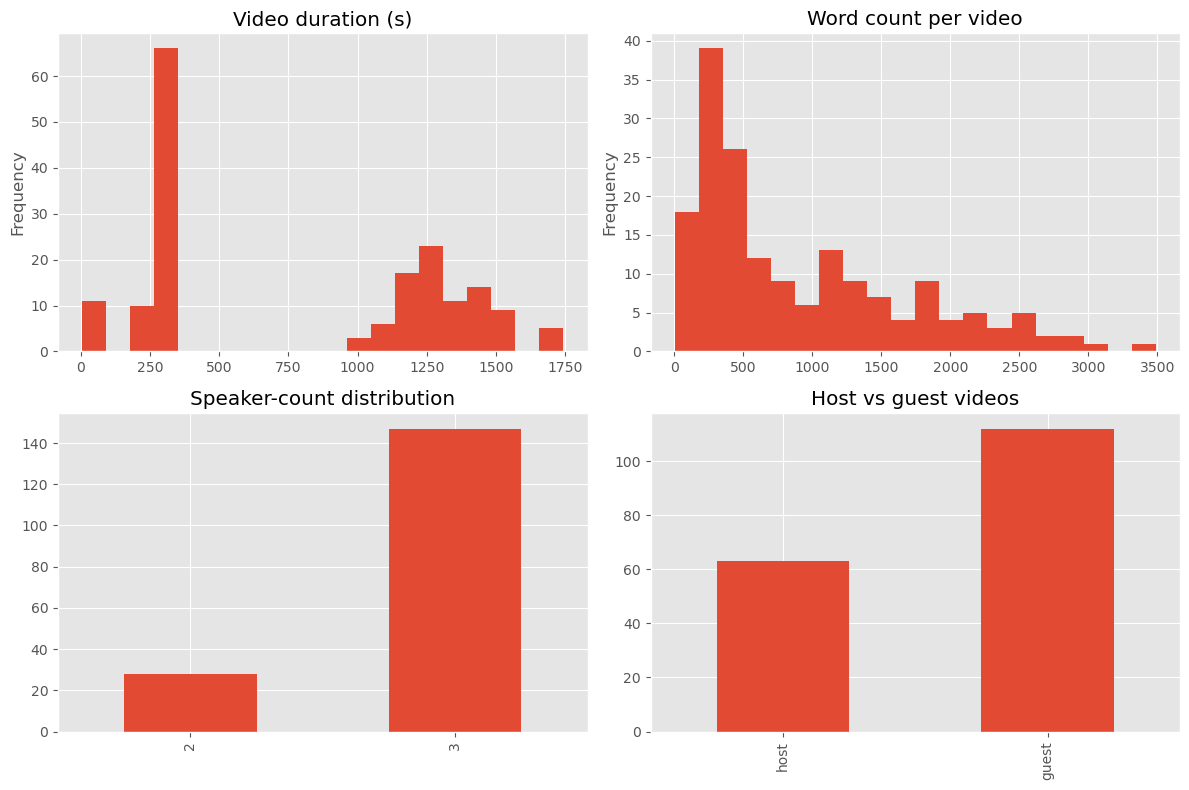

duration_seconds                 word_count  \
                                        count    mean  median      count   
speaker_is_host num_speakers                                               
False           2                          14  660.71   300.0         14   
                3                          98  818.22  1107.0         98   
True            2                          14  660.71   300.0         14   
                3                          49  818.22  1107.0         49   

                                               
                                 mean  median  
speaker_is_host num_speakers                   
False           2              552.71   256.0  
                3              709.19   536.5  
True            2             1187.57   556.0  
                3             1330.61  1431.0

In [3]:
overview = pd.DataFrame(
    {
        'metric': [
            'videos',
            'unique conversations',
            'host videos',
            'guest videos',
            'transcript rows',
            'transcript conversations',
            'annotation windows',
        ],
        'value': [
            len(video_info),
            video_info['conversation_id'].nunique(),
            int(video_info['speaker_is_host'].eq(True).sum()),
            int(video_info['speaker_is_host'].eq(False).sum()),
            len(transcripts),
            transcripts['conversation_id'].nunique(),
            len(windows),
        ],
    }
)

split_counts = pd.Series(
    {
        'train videos': int(video_info['train'].eq(True).sum()),
        'val videos': int(video_info['val'].eq(True).sum()),
        'test videos': int(video_info['test'].eq(True).sum()),
    },
    name='value',
)

display(overview)
display(split_counts.to_frame())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
video_info['duration_seconds'].dropna().plot(kind='hist', bins=20, ax=axes[0, 0], title='Video duration (s)')
video_info['word_count'].dropna().plot(kind='hist', bins=20, ax=axes[0, 1], title='Word count per video')
video_info['num_speakers'].dropna().value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], title='Speaker-count distribution')
pd.Series({
    'host': int(video_info['speaker_is_host'].eq(True).sum()),
    'guest': int(video_info['speaker_is_host'].eq(False).sum()),
}).plot(kind='bar', ax=axes[1, 1], title='Host vs guest videos')

for ax in axes.flat:
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

video_info.groupby(['speaker_is_host', 'num_speakers'])[['duration_seconds', 'word_count']].agg(['count', 'mean', 'median']).round(2)


## 2. Transcript and conversation dynamics

For a proactive assistant, the important signal is not just word volume. You also care about speaking turns, inter-speaker transitions, and timing gaps that may correspond to openings for intervention.


,conversation_id,transcript_rows,unique_speakers,first_word_time,last_word_time,speaker_switches,median_gap_to_next,p90_gap_to_next,transcript_duration,speaker_switch_rate_per_min
26,day_2__con_1__part4,2442,3,0.25,298.49,394,0.000,0.400,298.24,79.265021
4,day_1__con_1__part5,767,3,0.00,81.95,95,0.000,0.299,81.95,69.554606
52,day_5__con_4,10022,3,0.00,1236.20,1354,0.000,0.410,1236.20,65.717521
20,day_1__con_5__part3,2440,3,0.18,299.60,322,0.000,0.384,299.42,64.524748
12,day_1__con_3__part3,2594,3,0.18,297.00,312,0.001,0.114,296.82,63.068526
13,day_1__con_3__part4,650,3,1.29,82.23,80,0.000,0.272,80.94,59.303188
22,day_1__con_5__part5,47,2,0.00,4.05,4,0.000,0.016,4.05,59.259259
19,day_1__con_5__part2,2292,3,0.18,299.60,291,0.000,0.350,299.42,58.312738
41,day_3__con_5,9928,3,0.36,1383.67,1339,0.000,0.571,1383.31,58.078088
33,day_2__con_4,11121,3,0.06,1436.80,1347,0.000,0.460,1436.74,56.252349


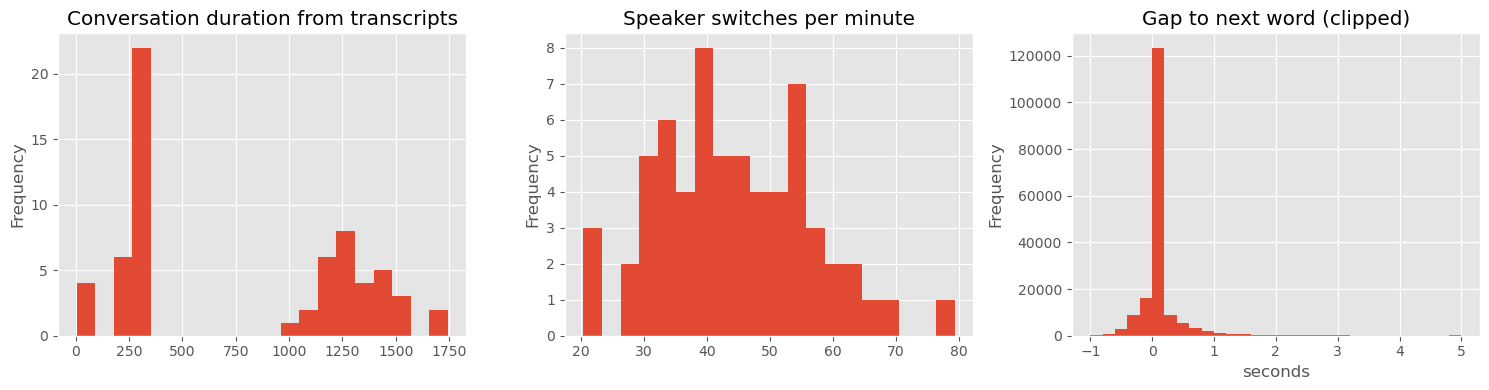

In [4]:
conversation_stats = (
    transcripts.sort_values(['conversation_id', 'startTime'])
    .assign(next_speaker=lambda df: df.groupby('conversation_id')['speaker_id'].shift(-1))
    .assign(next_start=lambda df: df.groupby('conversation_id')['startTime'].shift(-1))
    .assign(turn_change=lambda df: df['speaker_id'] != df['next_speaker'])
    .assign(gap_to_next=lambda df: df['next_start'] - df['endTime'])
)

per_conversation = conversation_stats.groupby('conversation_id').agg(
    transcript_rows=('word', 'count'),
    unique_speakers=('speaker_id', 'nunique'),
    first_word_time=('startTime', 'min'),
    last_word_time=('endTime', 'max'),
    speaker_switches=('turn_change', 'sum'),
    median_gap_to_next=('gap_to_next', 'median'),
    p90_gap_to_next=('gap_to_next', lambda s: s.dropna().quantile(0.9) if not s.dropna().empty else np.nan),
).reset_index()

per_conversation['transcript_duration'] = per_conversation['last_word_time'] - per_conversation['first_word_time']
per_conversation['speaker_switch_rate_per_min'] = per_conversation['speaker_switches'] / (per_conversation['transcript_duration'] / 60)

display(per_conversation.sort_values('speaker_switch_rate_per_min', ascending=False).head(10))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
per_conversation['transcript_duration'].dropna().plot(kind='hist', bins=20, ax=axes[0], title='Conversation duration from transcripts')
per_conversation['speaker_switch_rate_per_min'].replace([np.inf, -np.inf], np.nan).dropna().plot(kind='hist', bins=20, ax=axes[1], title='Speaker switches per minute')
conversation_stats['gap_to_next'].clip(lower=-1, upper=5).dropna().plot(kind='hist', bins=30, ax=axes[2], title='Gap to next word (clipped)')
axes[2].set_xlabel('seconds')
plt.tight_layout()
plt.show()


## 3. OcularClaw pilot slice

This section inspects the current 60-second host-perspective windows prepared for manual assistant-level annotation.


,metric,value
0,windows,18.00
1,unique conversations,4.00
2,avg words per window,185.00
3,avg turns per window,18.67


,conversation_id,start_sec,end_sec,window_word_count,window_speaker_count,transcript_turn_count
0,day_1__con_4__part1,0,60,205,3,29
1,day_1__con_4__part1,60,120,196,3,9
2,day_1__con_4__part1,120,180,171,3,9
3,day_1__con_4__part1,180,240,211,3,24
4,day_1__con_4__part2,0,60,143,3,17
5,day_1__con_4__part2,60,120,194,3,17
6,day_1__con_4__part2,120,180,230,3,22
7,day_1__con_4__part2,180,240,210,3,22
8,day_1__con_4__part2,240,300,168,3,31
9,day_1__con_4__part3,0,60,161,3,27


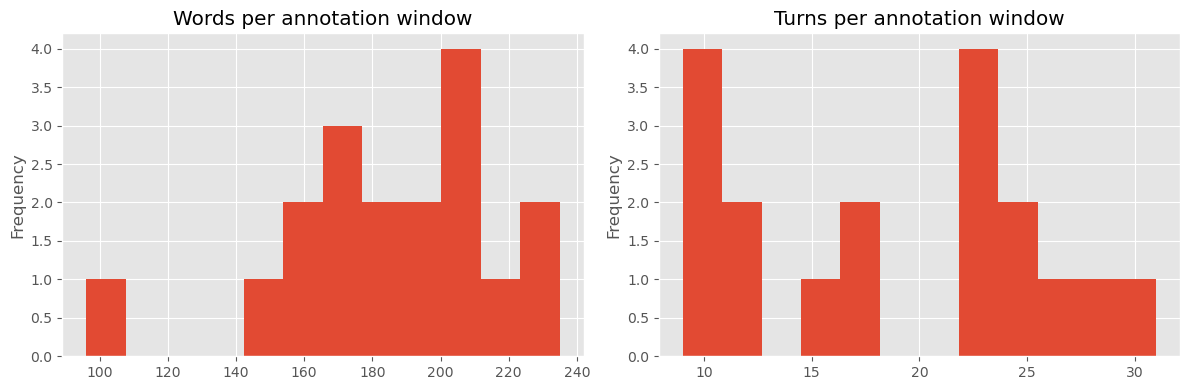

window_word_count                   transcript_turn_count  \
                                count    mean  min  max                 count   
conversation_id                                                                 
day_1__con_4__part1                 4  195.75  171  211                     4   
day_1__con_4__part2                 5  189.00  143  230                     5   
day_1__con_4__part3                 5  154.20   96  181                     5   
day_1__con_4__part4                 4  207.75  179  235                     4   

                                    
                      mean min max  
conversation_id                     
day_1__con_4__part1  17.75   9  29  
day_1__con_4__part2  21.80  17  31  
day_1__con_4__part3  16.40  10  27  
day_1__con_4__part4  18.50  10  25

In [5]:
window_summary = pd.DataFrame(
    {
        'metric': ['windows', 'unique conversations', 'avg words per window', 'avg turns per window'],
        'value': [
            len(windows),
            windows['conversation_id'].nunique(),
            round(windows['window_word_count'].mean(), 2),
            round(windows['transcript_turn_count'].mean(), 2),
        ],
    }
)

display(window_summary)
display(windows[['conversation_id', 'start_sec', 'end_sec', 'window_word_count', 'window_speaker_count', 'transcript_turn_count']].head(10))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
windows['window_word_count'].plot(kind='hist', bins=12, ax=axes[0], title='Words per annotation window')
windows['transcript_turn_count'].plot(kind='hist', bins=12, ax=axes[1], title='Turns per annotation window')
plt.tight_layout()
plt.show()

windows.groupby('conversation_id')[['window_word_count', 'transcript_turn_count']].agg(['count', 'mean', 'min', 'max']).round(2)


In [6]:
def show_window(row_index=0, transcript_preview_chars=1500):
    row = windows.iloc[row_index]
    print(f"window index: {row_index}")
    print(f"video_name: {row['video_name']}")
    print(f"conversation_id: {row['conversation_id']}")
    print(f"range: {int(row['start_sec'])}-{int(row['end_sec'])} seconds")
    print(f"word_count: {int(row['window_word_count'])}")
    print(f"turn_count: {int(row['transcript_turn_count'])}")
    print('\ntranscript preview:\n')
    print((row['transcript_text'] or '')[:transcript_preview_chars])

show_window(0)


window index: 0
video_name: vid_043__day_1__con_4__person_1_part1
conversation_id: day_1__con_4__part1
range: 0-60 seconds
word_count: 205
turn_count: 29

transcript preview:

[00:00.00] P1: So first question is to name three things that we all have in common Like and based on what we're wearing
[00:06.40] P3: Yeah All three of us
[00:09.45] P1: Yeah all three of us
[00:10.22] P2: Shirts pants and shoes laughing
[00:13.08] P1: That's very TRUE except you don't have pants you have shorts
[00:15.60] P2: Oh shorts but I call them pants usually
[00:17.67] P1: Oh yeah I would argue that our pants are not the same but we all have socks Do you have socks
[00:23.42] P2: Yes hidden socks
[00:24.71] P1: Oh secret socks
[00:25.87] P2: Yeah
[00:25.89] P1: Okay We all have socks shoes and shirts then
[00:28.26] P2: Okay
[00:28.72] P3: Think so
[00:29.02] P2: That works
[00:30.08] P1: Okay what about um something that one of us has that the other one doesn't And pants don't count cause we already co

In [7]:
clean_host_candidates = video_info.loc[
    video_info['speaker_is_host'].eq(True)
    & video_info['background_fan'].eq(False)
    & video_info['background_music'].eq(False)
].copy()

clean_host_candidates['split'] = np.select(
    [clean_host_candidates['train'].eq(True), clean_host_candidates['val'].eq(True), clean_host_candidates['test'].eq(True)],
    ['train', 'val', 'test'],
    default='unknown',
)

candidate_view = clean_host_candidates[
    ['video_name', 'conversation_id', 'split', 'num_speakers', 'duration_seconds', 'word_count']
].sort_values(['split', 'num_speakers', 'word_count'], ascending=[True, False, False])

display(candidate_view.head(20))

print('Tip: use this table to expand beyond the current 18-window pilot once your first annotation pass is stable.')


,video_name,conversation_id,split,num_speakers,duration_seconds,word_count
142,vid_143__day_5__con_4__person_1,day_5__con_4,test,3,1237,2299
151,vid_152__day_5__con_7__person_1,day_5__con_7,test,3,1160,1465
42,vid_043__day_1__con_4__person_1_part1,day_1__con_4__part1,test,3,291,572
43,vid_044__day_1__con_4__person_1_part2,day_1__con_4__part2,test,3,300,479
45,vid_046__day_1__con_4__person_1_part4,day_1__con_4__part4,test,3,261,454
44,vid_045__day_1__con_4__person_1_part3,day_1__con_4__part3,test,3,300,400
135,vid_136__day_5__con_1__person_1,day_5__con_1,test,2,1744,3490
109,vid_110__day_3__con_4__person_1,day_3__con_4,train,3,1512,3137
118,vid_119__day_4__con_1__person_1,day_4__con_1,train,3,1483,2904
103,vid_104__day_3__con_2__person_1,day_3__con_2,train,3,1328,2636


Tip: use this table to expand beyond the current 18-window pilot once your first annotation pass is stable.
